In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, find_peaks
from scipy.stats import entropy

import sys
sys.path.append("../LorenzCaosTest")
from Test_Chaos_noparallel import caostest10_noparallel 

from sum_time_series import (generate_sinusoidal_series, rndm, generate_power_law_series_negative, generate_inversely_related_series, 
                             calculate_spectral_entropy, perform_fft, identify_peaks, 
                             calculate_f1_score, calculate_f1_score_corrected, analyze_spectrum_detail, plot_exp_distrib)

# Studio entropia e caos

### primo esempio

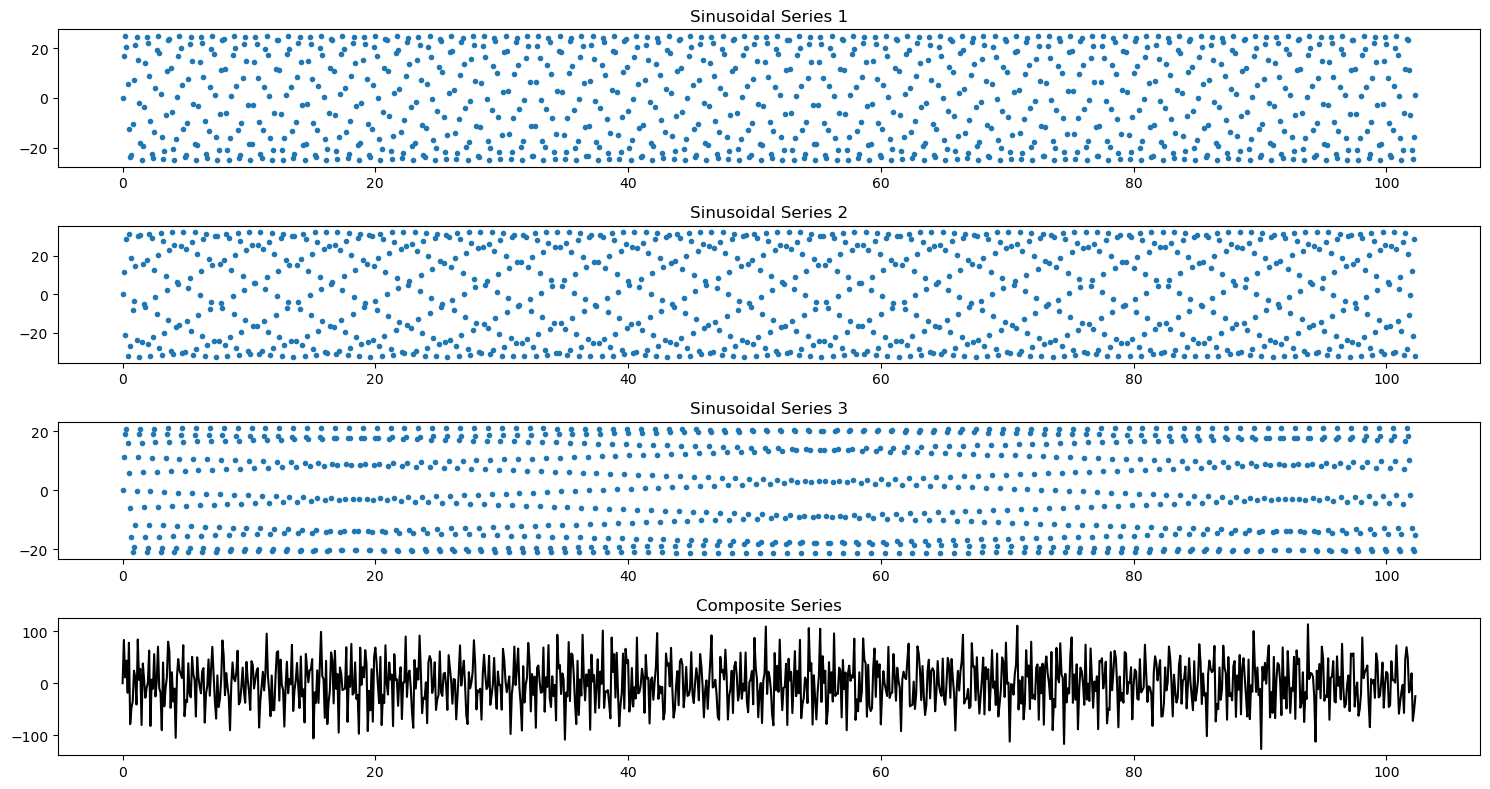

2.2326635053588144

In [2]:
# Parameters
n_series = 5    # Number of sinusoidal series to generate
series_length = 1024  # Length of each series
sampling_freq = 10# Sampling frequency in Hz

# Generate sinusoidal time series
series, time, _ = generate_sinusoidal_series(n_series, series_length, sampling_freq)

# Sum the series to form a composite time series
composite_series = np.sum(series, axis=0)

# Calculate the spectral entropy of the composite series
spectral_entropy = calculate_spectral_entropy(composite_series, sampling_freq)

# Plot the first few series and the composite series
plt.figure(figsize=(15, 8))

for i in range(min(3, n_series)):
    plt.subplot(4, 1, i+1)
    plt.plot(time, series[i], '.')
    plt.title(f"Sinusoidal Series {i+1}")

plt.subplot(4, 1, 4)
plt.plot(time, composite_series, 'k')
plt.title("Composite Series")
plt.tight_layout()
plt.show()

spectral_entropy

In [28]:
series[0].shape

(1024,)

### Ripeto con tante serie al variare del numero di serie sommate

In [3]:
n_series_fine_range = range(3, 51, 1)

# Numero di ripetizioni per ogni valore intero nel range
num_repetitions = 15

# Calcolare l'entropia spettrale per ogni numero di serie, ripetuto 20 volte
spectral_entropies_repetitions = []
chaos_ripetizioni = []
serie_generate = []

for n in n_series_fine_range:
    entropies = []
    chaoss = []
    for _ in range(num_repetitions):
        # Generate sinusoidal time series
        series, _, _ = generate_sinusoidal_series(n, series_length, sampling_freq)
        serie_generate.append(series)

        # Sum the series to form a composite time series
        composite_series = np.sum(series, axis=0)

        # Calculate the spectral entropy of the composite series
        entropy_value = calculate_spectral_entropy(composite_series, sampling_freq)
        chaos_value = caostest10_noparallel(composite_series)
        entropies.append(entropy_value)
        chaoss.append(chaos_value)

    # Calcolare la media delle entropie per ogni numero di serie
    average_entropy = np.mean(entropies)
    spectral_entropies_repetitions.append(average_entropy)
    
    avg_caos = np.mean(chaoss)
    chaos_ripetizioni.append(avg_caos)

Use coarser sampling or reduce the maximum value of c.
Use coarser sampling or reduce the maximum value of c.
Use coarser sampling or reduce the maximum value of c.
Use coarser sampling or reduce the maximum value of c.
Use coarser sampling or reduce the maximum value of c.
Use coarser sampling or reduce the maximum value of c.
Use coarser sampling or reduce the maximum value of c.
Use coarser sampling or reduce the maximum value of c.
Use coarser sampling or reduce the maximum value of c.
Use coarser sampling or reduce the maximum value of c.
Use coarser sampling or reduce the maximum value of c.
Use coarser sampling or reduce the maximum value of c.
Use coarser sampling or reduce the maximum value of c.
Use coarser sampling or reduce the maximum value of c.
Use coarser sampling or reduce the maximum value of c.
Use coarser sampling or reduce the maximum value of c.
Use coarser sampling or reduce the maximum value of c.
Use coarser sampling or reduce the maximum value of c.
Use coarse

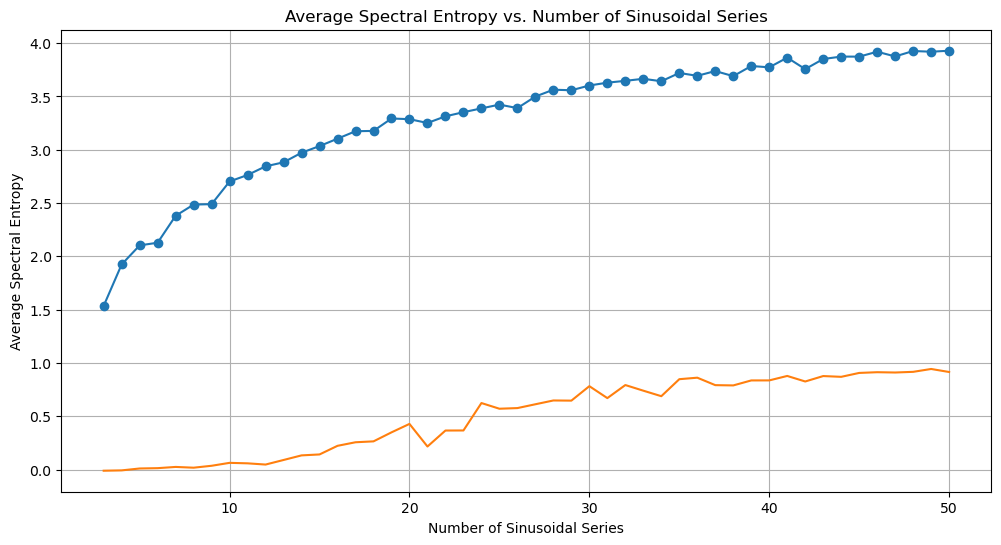

In [4]:
# Plotting the average spectral entropy for each number of series
plt.figure(figsize=(12, 6))
plt.plot(n_series_fine_range, spectral_entropies_repetitions, marker='o')
plt.plot(n_series_fine_range, chaos_ripetizioni )
plt.xlabel('Number of Sinusoidal Series')
plt.ylabel('Average Spectral Entropy')
plt.title('Average Spectral Entropy vs. Number of Sinusoidal Series')
plt.grid(True)
plt.show()

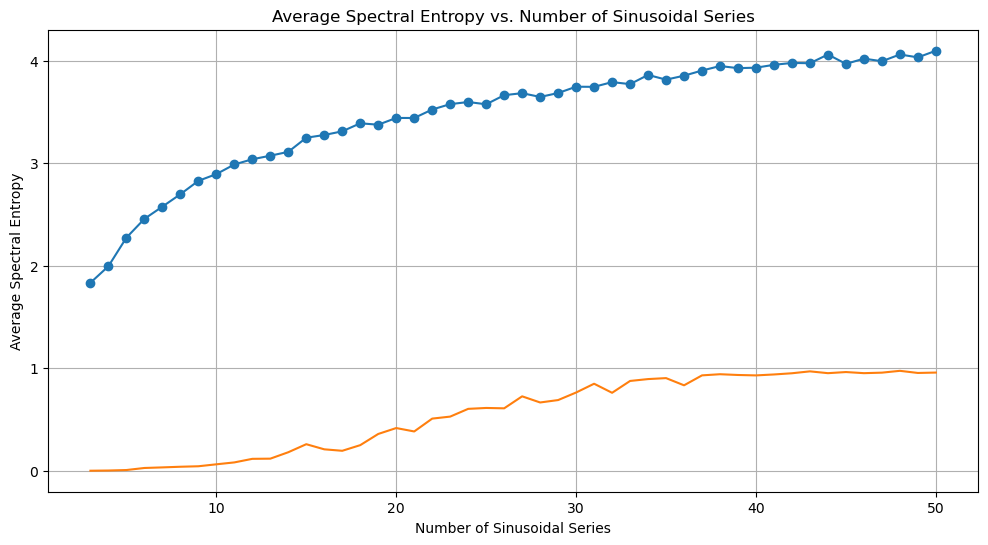

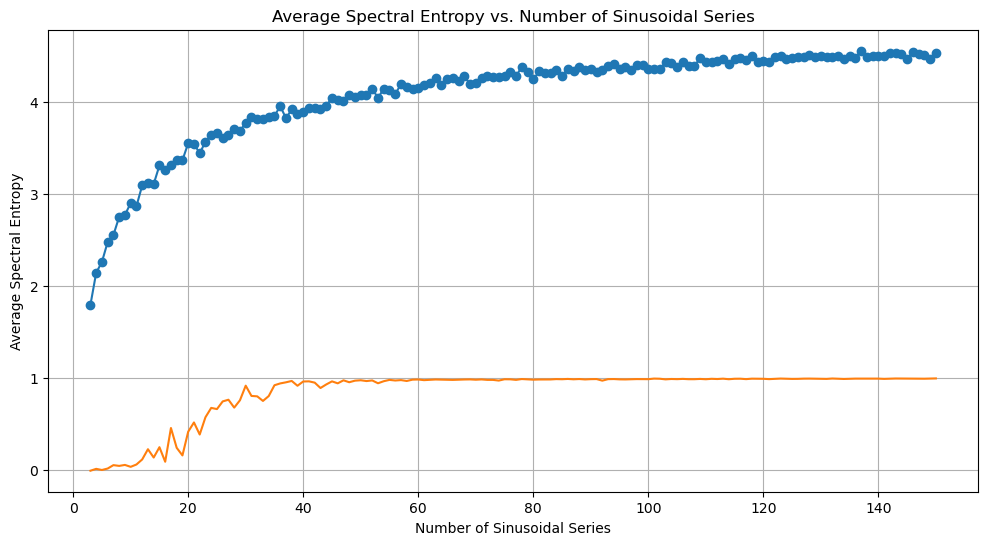

# ricostruzione con Fourier

In [2]:
series_length = 3600  # Length of each series
sampling_freq = 10# Sampling frequency in Hz

n_series_range = range(3, 51, 1)

# Numero di ripetizioni per ogni valore intero nel range
num_repetitions = 35


In [6]:


# Calcolare l'entropia spettrale per ogni numero di serie, ripetuto 20 volte
average_f1_scores = []
serie_generate = []

for n in n_series_range:
    f1_scores = []
    
    for _ in range(num_repetitions):
        # Generate sinusoidal time series
        series, ts, original_frequencies = generate_sinusoidal_series(n, series_length, sampling_freq)
        serie_generate.append(series)

        # Sum the series to form a composite time series
        composite_series = np.sum(series, axis=0)
        
        # Eseguire la FFT sulla serie composta
        frequencies, fft_magnitude = perform_fft(composite_series, sampling_freq)
        
        # Calcolare F1-score, precisione e richiamo
        f1_score, precision, recall, identified_frequencies = calculate_f1_score_corrected(original_frequencies, frequencies, fft_magnitude)
        f1_scores.append(f1_score)

    # Calcolare la media delle entropie per ogni numero di serie
    average_f1 = np.mean(f1_scores)
    average_f1_scores.append(average_f1)


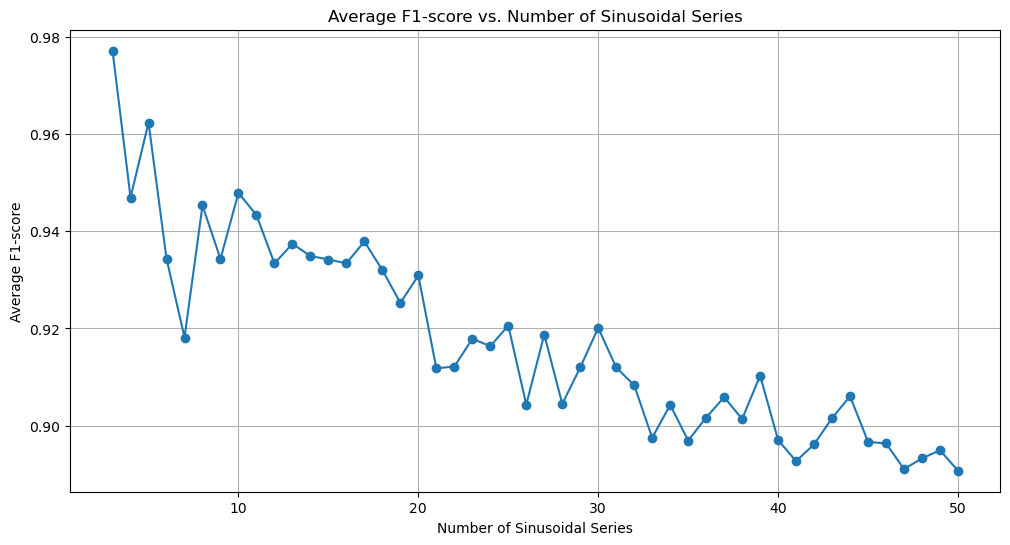

In [7]:
# Tracciare l'F1-score medio al variare del numero di serie sommate
plt.figure(figsize=(12, 6))
plt.plot(n_series_range, average_f1_scores, marker='o')
plt.xlabel('Number of Sinusoidal Series')
plt.ylabel('Average F1-score')
plt.title('Average F1-score vs. Number of Sinusoidal Series')
plt.grid(True)
plt.show()

### una singola prova

In [8]:
def crea_e_fft(series_length, sampling_freq, n):
    # Generate sinusoidal time series
    series, ts, original_frequencies = generate_sinusoidal_series(n, series_length, sampling_freq)

    # Sum the series to form a composite time series
    composite_series = np.sum(series, axis=0)

    # Eseguire la FFT sulla serie composta
    found_frequencies, fft_magnitude = perform_fft(composite_series, sampling_freq)

    # Calcolare F1-score, precisione e richiamo
    f1_score, precision, recall, identified_frequencies = calculate_f1_score_corrected(original_frequencies, found_frequencies, fft_magnitude)
    
    return f1_score, original_frequencies, found_frequencies, fft_magnitude
    

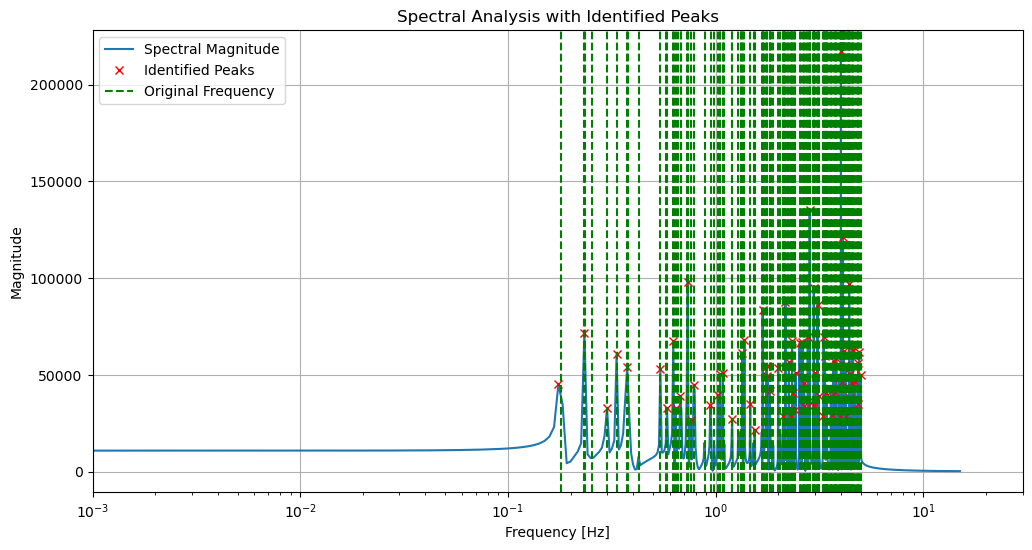

In [9]:
f1_score, original_frequencies, found_frequencies, fft_magnitude = crea_e_fft(series_length, sampling_freq, n=150)
identified_frequencies = analyze_spectrum_detail(original_frequencies, found_frequencies, fft_magnitude)

### verifica serie orignale e ricostruita con fourier

In [6]:


def reconstruct_time_series(identified_frequencies, fft_magnitude, length, fs):
    """
    Ricostruisce la serie temporale a partire dalle frequenze identificate e le loro ampiezze.
    
    Parameters:
    - identified_frequencies: Le frequenze identificate nella FFT.
    - fft_magnitude: L'ampiezza delle frequenze identificate.
    - length: La lunghezza della serie temporale originale.
    - fs: La frequenza di campionamento.
    
    Returns:
    - reconstructed_series: La serie temporale ricostruita.
    """
    t = np.arange(length) / fs
    reconstructed_series = np.zeros(length)
    
    for i, freq in enumerate(identified_frequencies):
        # Estrai ampiezza e fase dalla FFT
        amp = np.abs(fft_magnitude[i])# / (length/fs)  # Normalizzazione rispetto alla lunghezza del segnale
        phase = np.angle(fft_magnitude[i])
        reconstructed_series += amp * np.sin(2 * np.pi * freq * t + phase)
        
    num_identified_freq = len(identified_frequencies)
    
    return reconstructed_series / num_identified_freq

def verifica(n):
    series, ts, original_frequencies = generate_sinusoidal_series(n, series_length, sampling_freq)
    composite_series = np.sum(series, axis=0)
    found_frequencies, fft_magnitude = perform_fft(composite_series, sampling_freq)
    peaks, identified_frequencies = identify_peaks(fft_magnitude, found_frequencies)
    reconstructed_series = reconstruct_time_series(identified_frequencies, fft_magnitude, length=series_length, fs=sampling_freq)
    return composite_series, reconstructed_series, ts


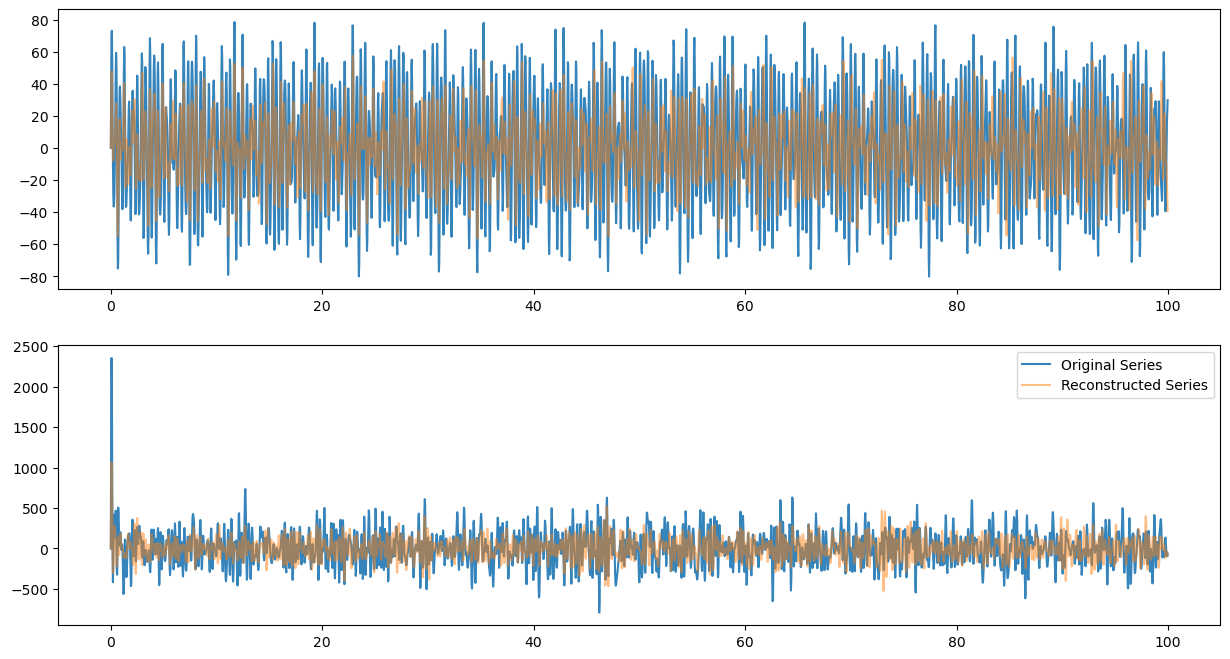

In [11]:
fig, ax = plt.subplots(2, 1, figsize=(15, 8))
i = 3000

composite_series, reconstructed_series, ts = verifica(n=5)
ts = ts[:i]
composite_series = composite_series[:i]
reconstructed_series = reconstructed_series[:i]
ax[0].plot(ts, composite_series, label='Original Series', alpha=0.9)
ax[0].plot(ts, reconstructed_series/4, label='Reconstructed Series', alpha=0.5)


composite_series, reconstructed_series, ts = verifica(n=150)
ts = ts[:i]
composite_series = composite_series[:i]
reconstructed_series = reconstructed_series[:i]
ax[1].plot(ts, composite_series, label='Original Series', alpha=0.9)
ax[1].plot(ts, reconstructed_series/10, label='Reconstructed Series', alpha=0.5)

plt.legend()

# volatilita' per paragone con le serie dei prezzi

In [12]:
def volatility(serie):
    serie = serie + 1000 # per gestire i valori negativi
    log_returns = np.log(serie / np.roll(serie, 1))
    log_returns[0] = 0
    volatility = log_returns.std()
    return volatility

In [147]:
volatility(composite_series)

0.061585897829021734

# frequenze e ampiezze a legge di potenza

### f1 score

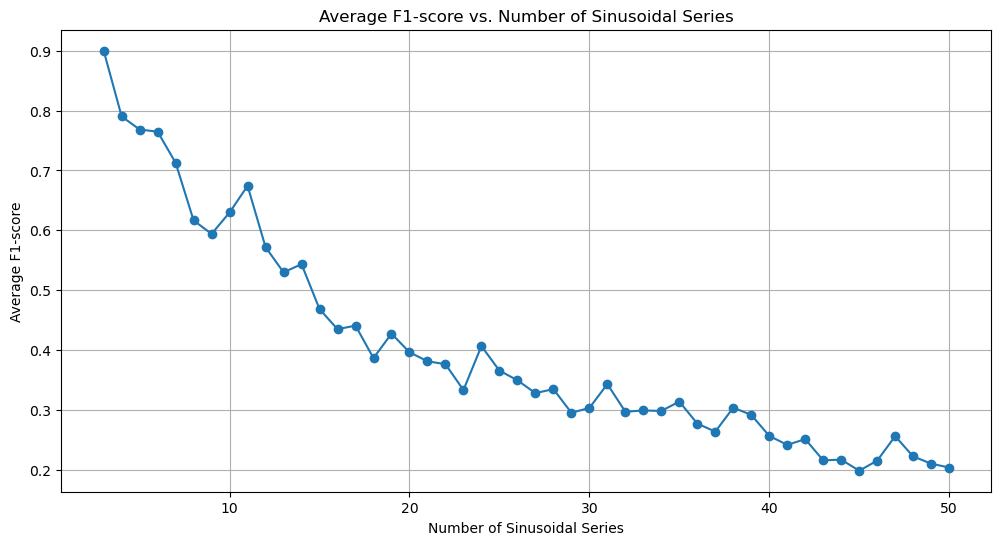

In [3]:
# Calcolare l'entropia spettrale per ogni numero di serie, ripetuto 20 volte
average_f1_scores = []
serie_generate = []

for n in n_series_range:
    f1_scores = []
    
    for _ in range(num_repetitions):
        # Generate sinusoidal time series
        series, ts, original_frequencies, _ = generate_power_law_series_negative(n, series_length, sampling_freq, freq_range=(0.02, 5), amp_range=(0.05, 100))
        serie_generate.append(series)

        # Sum the series to form a composite time series
        composite_series = np.sum(series, axis=0)
        
        # Eseguire la FFT sulla serie composta
        frequencies, fft_magnitude = perform_fft(composite_series, sampling_freq)
        
        # Calcolare F1-score, precisione e richiamo
        f1_score, precision, recall, identified_frequencies = calculate_f1_score_corrected(original_frequencies, frequencies, fft_magnitude)
        f1_scores.append(f1_score)

    # Calcolare la media delle entropie per ogni numero di serie
    average_f1 = np.mean(f1_scores)
    average_f1_scores.append(average_f1)

# Tracciare l'F1-score medio al variare del numero di serie sommate
plt.figure(figsize=(12, 6))
plt.plot(n_series_range, average_f1_scores, marker='o')
plt.xlabel('Number of Sinusoidal Series')
plt.ylabel('Average F1-score')
plt.title('Average F1-score vs. Number of Sinusoidal Series')
plt.grid(True)
plt.show()

### frequenze e ampiezze totalmente random

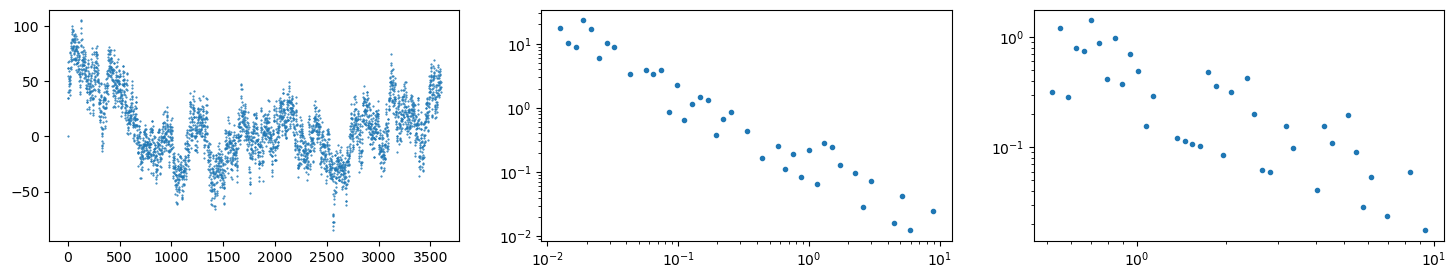

In [13]:
negative_power_law_series, ts, negative_power_law_freqs, negative_power_law_amps = generate_power_law_series_negative(
    n=100, length=series_length, fs=sampling_freq, exponent=-1.1, freq_range=(0.01, 10), amp_range=(0.5, 10))
negative_power_law_composite_series = np.sum(negative_power_law_series, axis=0)

fig, ax = plt.subplots(1, 3, figsize=(18, 3))
ax[0].plot(negative_power_law_composite_series, '.', markersize=1)

freq_dist = plot_exp_distrib(negative_power_law_freqs)
ax[1].plot(*freq_dist, '.') 
ax[1].set_xscale('log')
ax[1].set_yscale('log')
amp_dist = plot_exp_distrib(negative_power_law_amps)
ax[2].plot(*amp_dist, '.')
ax[2].set_xscale('log')
ax[2].set_yscale('log')
plt.show()

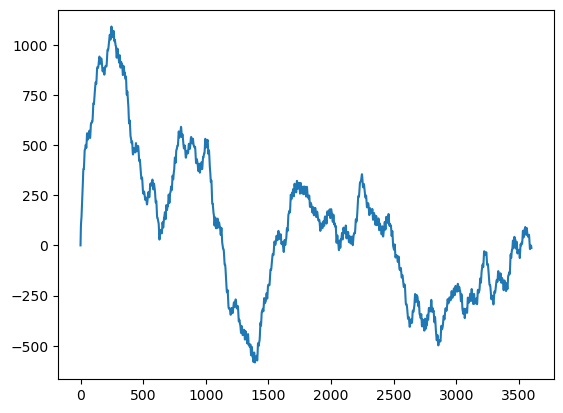

### frequenze e ampiezze un po' collegate tra loro

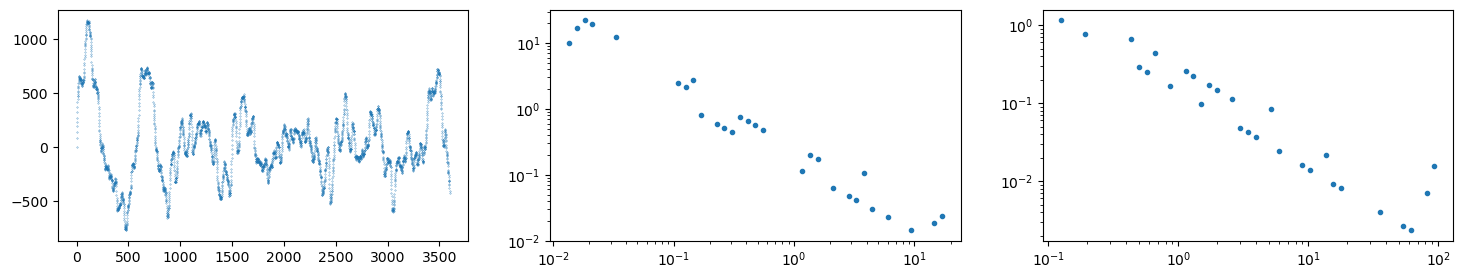

In [7]:
negative_power_law_series, ts, negative_power_law_freqs, negative_power_law_amps = generate_inversely_related_series(
    n=50, length=series_length, fs=sampling_freq, exponent=-1.1, freq_range=(0.01, 30), amp_range=(0.05, 100), C=2)

negative_power_law_composite_series = np.sum(negative_power_law_series, axis=0)

fig, ax = plt.subplots(1, 3, figsize=(18, 3))
ax[0].plot(negative_power_law_composite_series, '.', markersize=0.5)

freq_dist = plot_exp_distrib(negative_power_law_freqs)
ax[1].plot(*freq_dist, '.') 
ax[1].set_xscale('log')
ax[1].set_yscale('log')
amp_dist = plot_exp_distrib(negative_power_law_amps)
ax[2].plot(*amp_dist, '.')
ax[2].set_xscale('log')
ax[2].set_yscale('log')
plt.show()

#plt.figure(figsize=(18,5))
#plt.plot(negative_power_law_composite_series, '.', markersize=1)

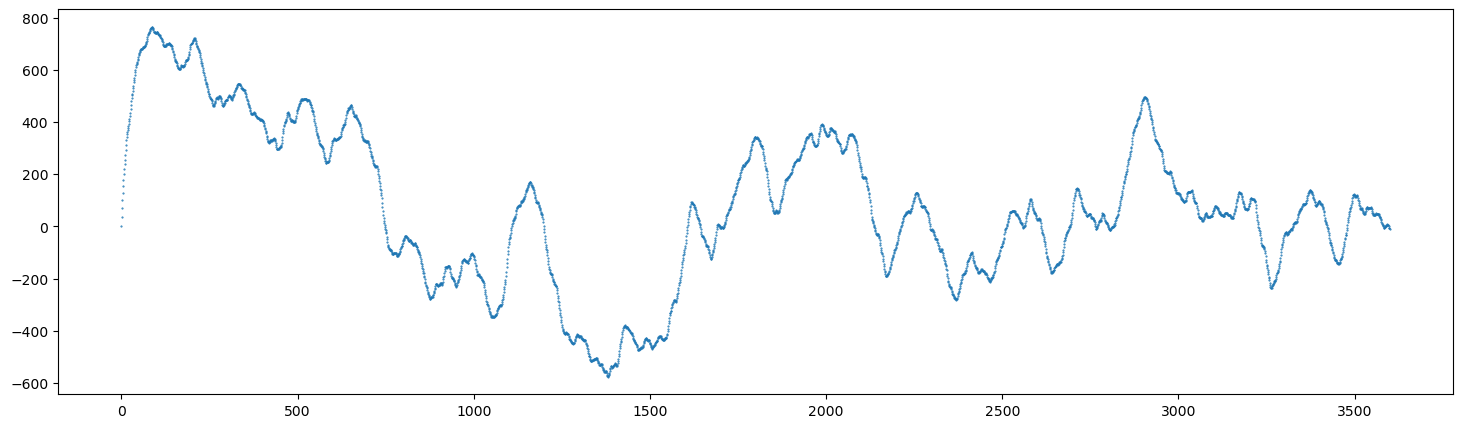

##### verfica per le dist. esponenziali negative

In [85]:
freq_range=(0.001, 1000)
pos_alpha = 2
n = 15000
freqs = freq_range[1] - (freq_range[1] - freq_range[0]) * np.random.power(pos_alpha, size=n)
bins = np.logspace(np.log10(freq_range[0]), np.log10(freq_range[1]), 50)

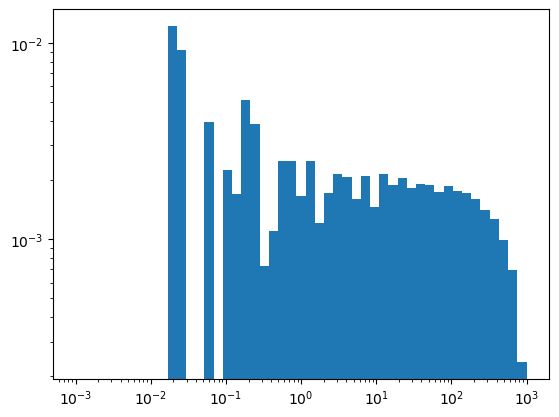

In [86]:
plt.hist(freqs, bins=bins, density=True)
plt.xscale('log')
plt.yscale('log')
plt.show()

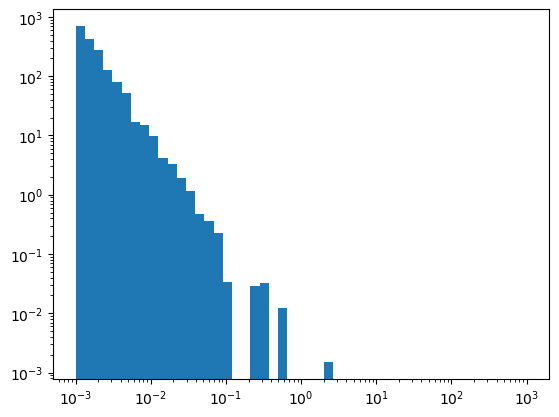

In [95]:
dist = rndm(freq_range[0], freq_range[1], exponent=-2, size=1000)
bins = np.logspace(np.log10(freq_range[0]), np.log10(freq_range[1]), 50)
plt.hist(dist, bins=bins, density=True)
plt.xscale('log')
plt.yscale('log')
plt.show()

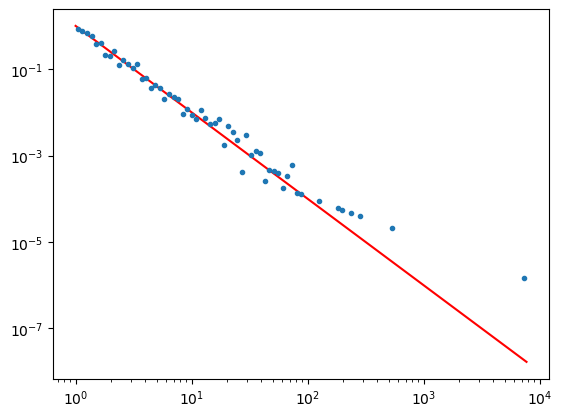

In [96]:
import powerlaw

exp, xmin = 2.0, 1.0
N = 1000

# generates random variates of power law distribution
vrs = powerlaw.Power_Law(xmin=xmin, parameters=[exp]).generate_random(N)

# plotting the PDF estimated from variates
bin_min, bin_max = np.min(vrs), np.max(vrs)
bins = 10**(np.linspace(np.log10(bin_min), np.log10(bin_max), 100))
counts, edges = np.histogram(vrs, bins, density=True)
centers = (edges[1:] + edges[:-1])/2.

# plotting the expected PDF 
xs = np.linspace(bin_min, bin_max, 100000)
plt.plot(xs, [(exp-1)*xmin**(exp-1)*x**(-exp) for x in xs], color='red')
plt.plot(centers, counts, '.')

plt.xscale('log')
plt.yscale('log')

## ricostruzione

### freq e amp random

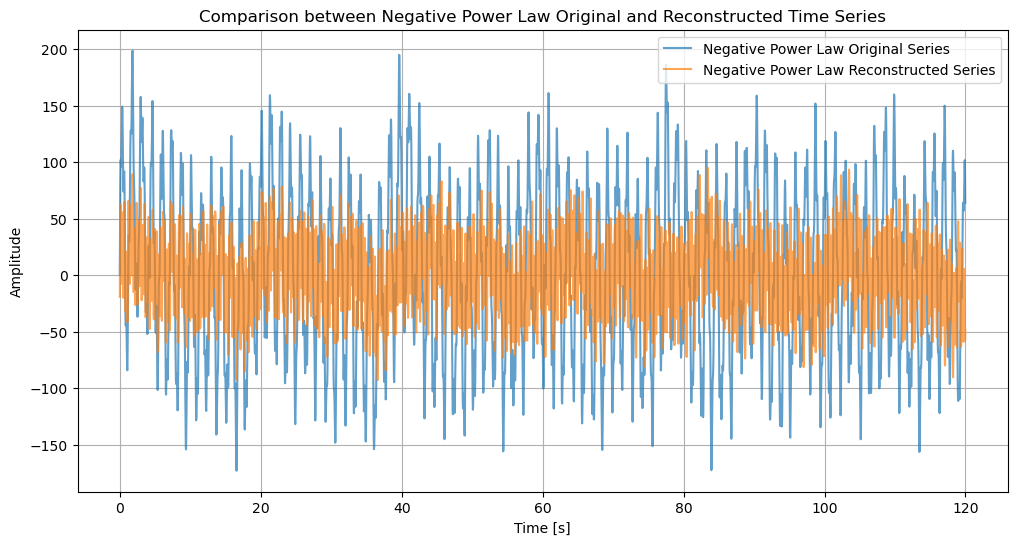

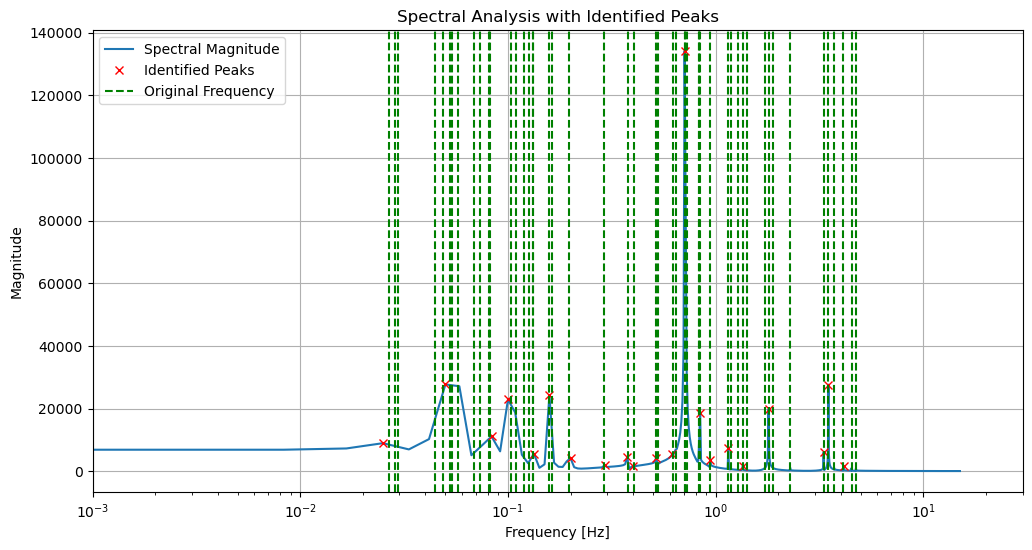

In [15]:
# Esempio di utilizzo con esponente negativo
negative_power_law_series, ts, negative_power_law_freqs, negative_power_law_amps = generate_power_law_series_negative(
    n=50, length=series_length, fs=sampling_freq, exponent=-1.1, freq_range=(0.02, 5), amp_range=(0.05, 100))

# Somma delle serie per ottenere la serie composta
negative_power_law_composite_series = np.sum(negative_power_law_series, axis=0)

# Eseguire la FFT sulla serie composta
negative_power_law_found_frequencies, negative_power_law_fft_magnitude = perform_fft(negative_power_law_composite_series, sampling_freq)

# Calcolo F1-score, precisione e richiamo
negative_power_law_f1_score, negative_power_law_precision, negative_power_law_recall, negative_power_law_identified_frequencies = calculate_f1_score_corrected(
    negative_power_law_freqs, negative_power_law_found_frequencies, negative_power_law_fft_magnitude)

# Ricostruzione della serie temporale con legge di potenza inversa
negative_power_law_fft_values = np.fft.fft(negative_power_law_composite_series)
negative_power_law_reconstructed_series = reconstruct_time_series(
    negative_power_law_identified_frequencies, negative_power_law_fft_values, length=series_length, fs=sampling_freq)

# Plot delle serie temporali originali e ricostruite
plt.figure(figsize=(12, 6))
plt.plot(ts, negative_power_law_composite_series, label='Negative Power Law Original Series', alpha=0.7)
plt.plot(ts, negative_power_law_reconstructed_series/100, label='Negative Power Law Reconstructed Series', alpha=0.7)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Comparison between Negative Power Law Original and Reconstructed Time Series')
plt.legend()
plt.grid(True)
plt.show()

analyze_spectrum_detail(negative_power_law_freqs, negative_power_law_found_frequencies, negative_power_law_fft_magnitude, tolerance=0.01)

### freq e amp collegate

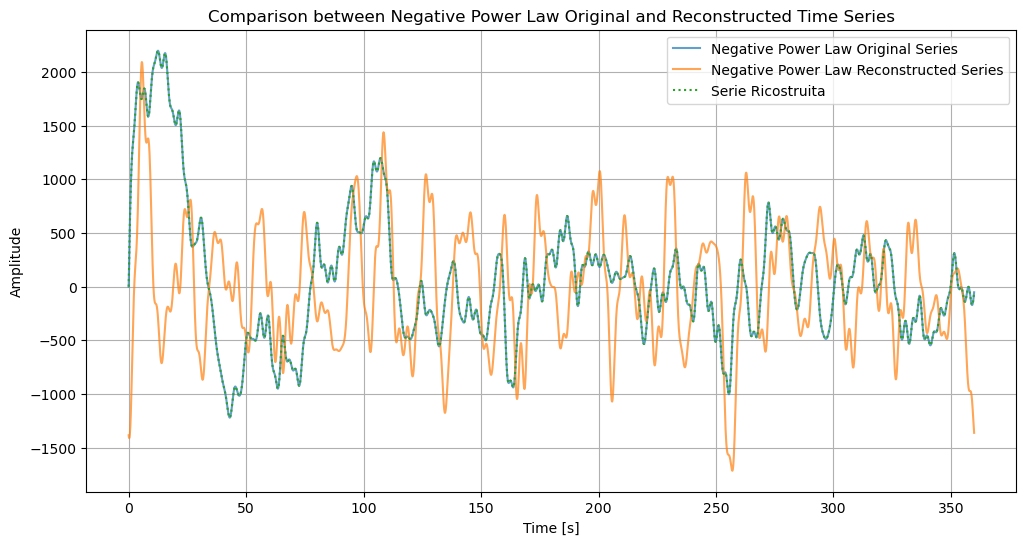

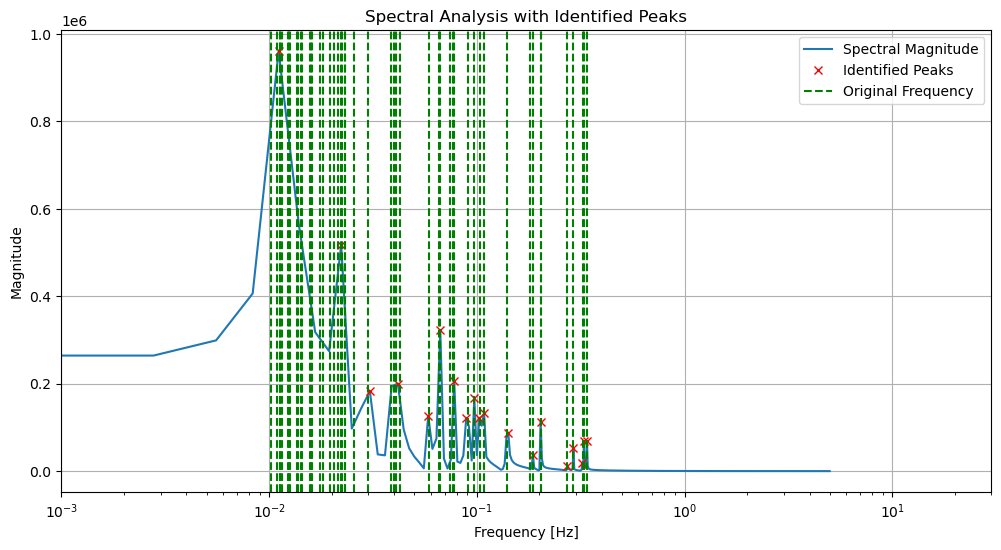

In [13]:
negative_power_law_series, ts, negative_power_law_freqs, negative_power_law_amps = generate_inversely_related_series(
    n=50, length=series_length, fs=sampling_freq, exponent=-1.5, freq_range=(0.01, 0.5), amp_range=(0.01, 100), C=3)

# Somma delle serie per ottenere la serie composta
negative_power_law_composite_series = np.sum(negative_power_law_series, axis=0)

# Eseguire la FFT sulla serie composta
negative_power_law_found_frequencies, negative_power_law_fft_magnitude = perform_fft(negative_power_law_composite_series, sampling_freq)
# risultati completi
n = len(negative_power_law_composite_series)
f = np.fft.fftfreq(n, 1/sampling_freq)
fft_values = np.fft.fft(negative_power_law_composite_series)
#return f[:n // 2], np.abs(fft_values)[:n // 2] 

# Identifica i picchi
peaks, negative_power_law_identified_frequencies = identify_peaks(negative_power_law_fft_magnitude, negative_power_law_found_frequencies, height=0.01)

# Ricostruzione della serie temporale con legge di potenza inversa
negative_power_law_fft_values = np.fft.fft(negative_power_law_composite_series)
negative_power_law_reconstructed_series = reconstruct_time_series(
    negative_power_law_identified_frequencies, negative_power_law_fft_values, length=series_length, fs=sampling_freq)

# Plot delle serie temporali originali e ricostruite
plt.figure(figsize=(12, 6))
plt.plot(ts, negative_power_law_composite_series, label='Negative Power Law Original Series', alpha=0.7)
plt.plot(ts, negative_power_law_reconstructed_series/100, label='Negative Power Law Reconstructed Series', alpha=0.7)

reconstructed_series = np.fft.ifft(fft_values)
reconstructed_series = np.real(reconstructed_series)
plt.plot(ts, reconstructed_series, label="Serie Ricostruita", linestyle=':')

plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Comparison between Negative Power Law Original and Reconstructed Time Series')
plt.legend()
plt.grid(True)
plt.show()

analyze_spectrum_detail(negative_power_law_freqs, negative_power_law_found_frequencies, negative_power_law_fft_magnitude, tolerance=0.01)

##### $\rightarrow $ Quindi lo spettro di fourier e' sufficiente per ricostruire la serie soltanto per costruzione del metodo, ma non riesce ad avere la risoluzione necessaria per ritrovare tutte le componenti originali vere, cioe' non ritrova dei picchi che siano osservabili (marker rossi)

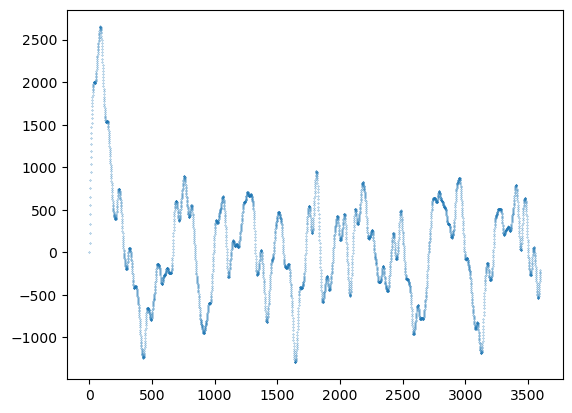

In [146]:
plt.plot(negative_power_law_composite_series, '.', markersize=0.5)

In [440]:
# si vede proprio che la trasformata di fourier non je la fa manco da lontano a ritrovare le freuenze originali...

## f1score con freq e amp correlate

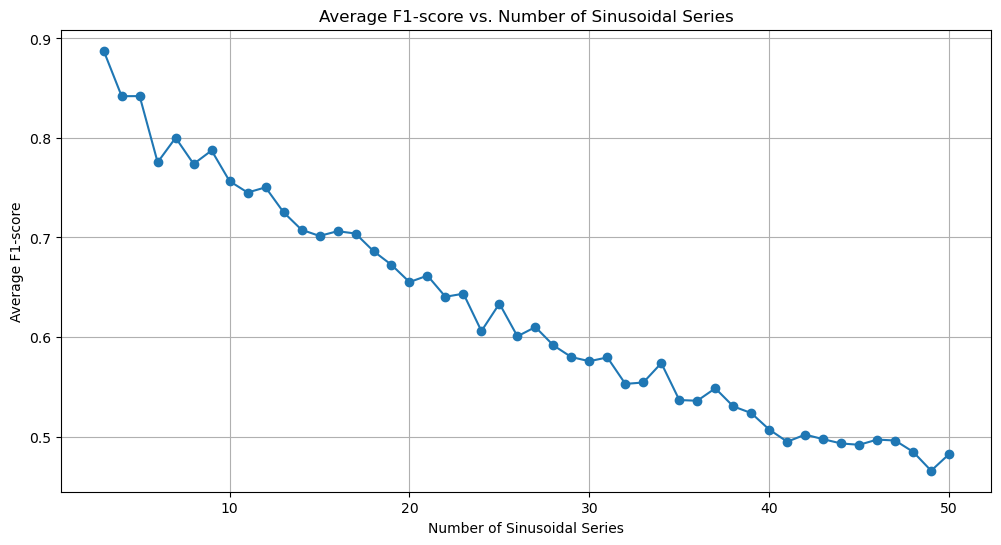

In [16]:
# Calcolare l'entropia spettrale per ogni numero di serie, ripetuto 20 volte
average_f1_scores = []
serie_generate = []

for n in n_series_range:
    f1_scores = []
    
    for _ in range(num_repetitions):
        # Generate sinusoidal time series
        #series, ts, original_frequencies, _ = generate_power_law_series_negative(n, series_length, sampling_freq, freq_range=(0.02, 5), amp_range=(0.05, 100))
        series, ts, original_frequencies, _ = generate_inversely_related_series(n, series_length, sampling_freq, exponent=-1.1, freq_range=(0.01, 30), amp_range=(0.05, 100), C=2)
        serie_generate.append(series)

        # Sum the series to form a composite time series
        composite_series = np.sum(series, axis=0)
        
        # Eseguire la FFT sulla serie composta
        frequencies, fft_magnitude = perform_fft(composite_series, sampling_freq)
        
        # Calcolare F1-score, precisione e richiamo
        f1_score, precision, recall, identified_frequencies = calculate_f1_score_corrected(original_frequencies, frequencies, fft_magnitude, height=0.01)
        f1_scores.append(f1_score)

    # Calcolare la media delle entropie per ogni numero di serie
    average_f1 = np.mean(f1_scores)
    average_f1_scores.append(average_f1)

# Tracciare l'F1-score medio al variare del numero di serie sommate
plt.figure(figsize=(12, 6))
plt.plot(n_series_range, average_f1_scores, marker='o')
plt.xlabel('Number of Sinusoidal Series')
plt.ylabel('Average F1-score')
plt.title('Average F1-score vs. Number of Sinusoidal Series')
plt.grid(True)
plt.show()

# Prova con generazione serie singola a partire da rumore bianco e spettro a legge di potenza

/tmp/ipykernel_3161668/3533476898.py:25: RuntimeWarning: divide by zero encountered in power
  factor = np.abs(frequencies) ** (-alpha / 2.0)


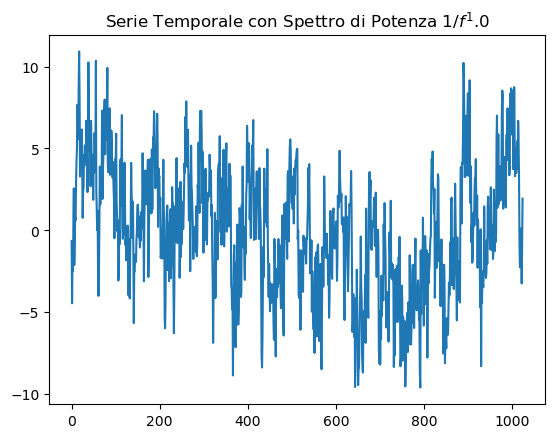

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def generate_power_law_series(n, alpha):
    """
    Genera una serie temporale con uno spettro che segue una legge di potenza con esponente negativo.
    
    Parameters:
        n (int): Lunghezza della serie temporale.
        alpha (float): Esponente della legge di potenza (positiva per uno spettro decrescente con la frequenza).
    
    Returns:
        np.ndarray: Serie temporale generata.
    """
    # Genera rumore bianco
    white_noise = np.random.normal(size=n)
    
    # Trasformata di Fourier del rumore bianco
    fourier_transform = np.fft.fft(white_noise)
    
    # Frequenze corrispondenti
    frequencies = np.fft.fftfreq(n)
    
    # Applica la legge di potenza nel dominio delle frequenze
    factor = np.abs(frequencies) ** (-alpha / 2.0)
    factor[0] = 0  # Evita la divisione per zero
    
    # Applica il filtro
    filtered_transform = fourier_transform * factor
    
    # Trasformata inversa per tornare nel dominio del tempo
    time_series = np.fft.ifft(filtered_transform)
    
    # Prende la parte reale (l'immaginario dovrebbe essere trascurabile)
    return np.real(time_series)

# Esempio di utilizzo
n = 1024
alpha = 1.0  # Scegli un esponente, es. 1 per rumore rosa
series = generate_power_law_series(n, alpha)

# Visualizza la serie temporale generata
plt.plot(series)
plt.title(f'Serie Temporale con Spettro di Potenza $1/f^{alpha}$')
plt.show()


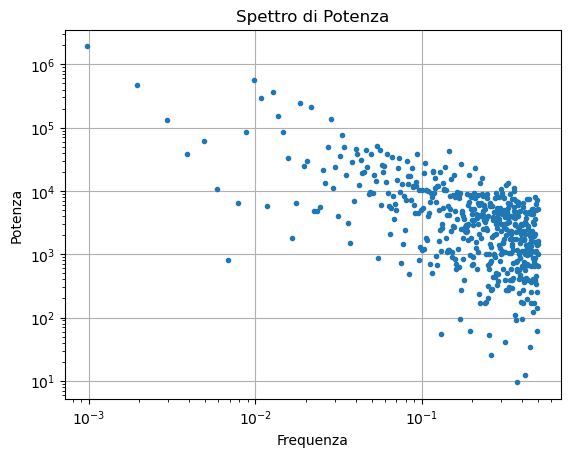

In [11]:
def plot_power_spectrum(series, sampling_rate=1.0):
    """
    Calcola e visualizza lo spettro di potenza di una serie temporale.

    Parameters:
        series (np.ndarray): Serie temporale da analizzare.
        sampling_rate (float): Frequenza di campionamento della serie temporale.
    
    Returns:
        None
    """
    # Calcola la trasformata di Fourier
    fourier_transform = np.fft.fft(series)
    
    # Calcola le frequenze corrispondenti
    frequencies = np.fft.fftfreq(len(series), d=sampling_rate)
    
    # Calcola lo spettro di potenza
    power_spectrum = np.abs(fourier_transform) ** 2
    
    # Prendi solo la parte positiva dello spettro e delle frequenze
    positive_frequencies = frequencies[frequencies > 0]
    positive_power_spectrum = power_spectrum[frequencies > 0]
    
    # Visualizza lo spettro di potenza in scala log-log
    plt.loglog(positive_frequencies, positive_power_spectrum, '.')
    plt.title('Spettro di Potenza')
    plt.xlabel('Frequenza')
    plt.ylabel('Potenza')
    plt.grid(True)
    plt.show()

# Verifica dello spettro della serie generata
plot_power_spectrum(series)
